In [17]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026")
data = pd.read_csv(os.path.join(path, 'gold_data.csv'))

In [18]:
df = data.copy()

In [19]:
df = df.set_index("Date")

In [20]:
df.loc['2002-02-14']

Gold_Open        300.000000
Gold_High        300.500000
Gold_Low         299.399994
Gold_Close       299.700012
Gold_Volume       20.000000
DXY              118.430000
SP500           1116.479980
Oil               21.219999
VIX               21.770000
Lag1             299.399994
Lag7             298.200012
MA7              300.085720
MA30             287.063333
EMA20            291.962793
Daily_Return       0.001002
RSI               68.829643
MACD               5.500935
MACD_Signal        4.344156
MACD_Hist          1.156780
BB_Upper         307.481856
BB_Middle        289.115001
BB_Lower         270.748146
ATR                3.761646
Target           298.399994
Name: 2002-02-14, dtype: float64

In [21]:
df.columns

Index(['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
       'DXY', 'SP500', 'Oil', 'VIX', 'Lag1', 'Lag7', 'MA7', 'MA30', 'EMA20',
       'Daily_Return', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'ATR', 'Target'],
      dtype='str')

In [22]:
y = df['Target']
X = df.drop(columns=['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Volume', 'ATR', 'Target'])

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

s_train = scaler.fit_transform(X_train)
s_test = scaler.transform(X_test)

X_train = pd.DataFrame(s_train, columns = X.columns, index = X_train.index)
X_test = pd.DataFrame(s_test, columns = X.columns, index = X_test.index)

In [25]:
from GoldPricePredictor import GoldPricePredictor

model = GoldPricePredictor()
model.train(X_train, y_train, es_patience=10)

TypeError: GoldPricePredictor.train() got an unexpected keyword argument 'es_patience'

RMSE : 56.053335170283674
MAE  : 34.85103139037144
R²   : 0.9966760649464707


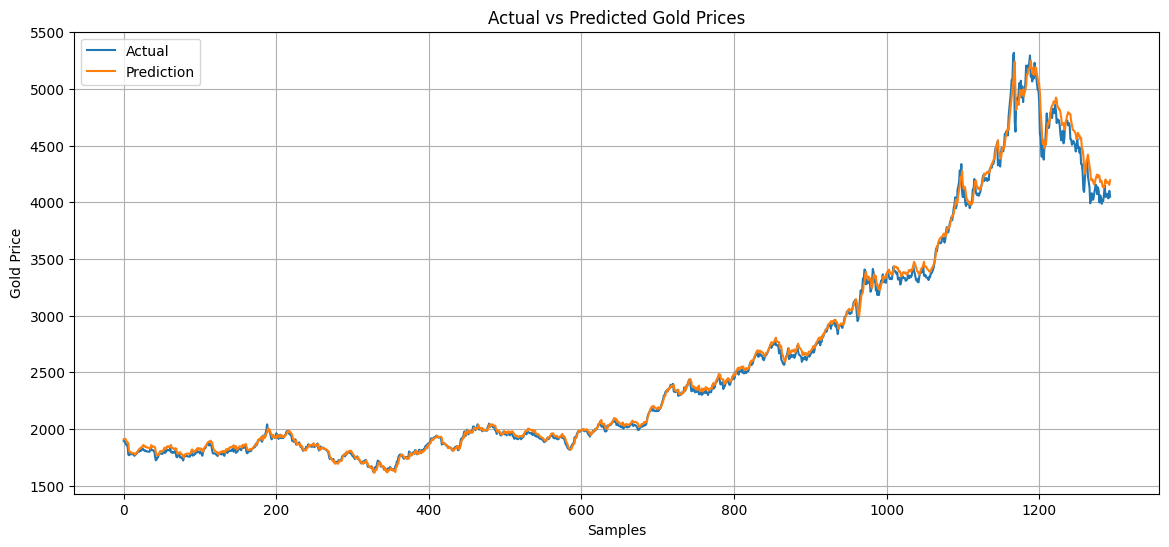

In [ ]:
model.evaluate(X_test, y_test)